# Seismic Wind Workflow

#### A Tutorial by Simon Ramirez

This notebook details the process for investigating wind speed and direction through seismic analysis, using seismicwind.py

The example seismic file CWA86_example.mseed is required for this tutorial.

## 0. Imports and Setup

In [ ]:
# For Configuration File
import yaml
from pathlib import Path
import importlib
import numpy as np

config_path = ### Enter Config File Path Here

# Load Config File
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

# Config Variables
name = config["name"]
seismic_path = config["seismic_data_path"]
seismic_data = Path(config['seismic_data_path'])
aws_path = config['aws_data_path']
seiswind_module = config['seiswind_module']

# obspy GitHub:
# https://github.com/obspy/obspy
from obspy import UTCDateTime as UTC

# seismic-weather GitHub:
# https://github.com/Ramirezs873/seismic-weather
spec = importlib.util.spec_from_file_location("seismicwind", seiswind_module)
seismicwind = importlib.util.module_from_spec(spec)
spec.loader.exec_module(seismicwind)

In [3]:
# Load class Seismic
## Load with config file
seis = seismicwind.Seismic(config=config)

## 1. Load Seismic Data

For a full seismic data and preprocessing tutorial, see Seismic_Data_Tutorial.ipynb

For this workflow, preprocessed seismic data is used. The station is CWA86, which is close to the AWS at Casey Skiway.

The seismic data is from 2022 Dec 24th 11pm to 2023 Jan 1st 1am. It has been rotation corrected, demeaned, detrended, and hann windowed. 

In [5]:
# Gather Data
## Station CASY used as an example
data = seis.get_seis(client = None, 
                     network = None, 
                     station = None,
                     location = None, 
                     channel = None,
                     t_start = None,
                     t_end = None,
                     username = None, 
                     password = None,
                     file_name = 'CWA86_example')

Reading existing file: C:\Users\simon\Desktop\UTAS\Honours Research\Workspace\CWA86_example.mseed


## 2. Load AWS Data

For a full aws data tutorial, see AWS_Data_Tutorial.ipynb

In [6]:
aws = data.wind.get_aws(path=aws_path, station_code='300060', id_code='55510926053')

Gather wind data. Timespan must exist within the seismic data timespan.

In [7]:
wind = data.wind.get_var(variable='Wind speed in km/h',
                         year = 2022, 
                         month = 12, 
                         day = (25,31), 
                         hour = None) # None returns all

## 3. Fast Fourier Transform

For further seismic-wind analysis, the Seismic().wind.seismicwind subclass is used.

Apply a FFT to the seismic data using the function spectra_fft().

In [29]:
FFT = data.wind.seismic_wind.spectra_fft(pad_value=np.nan)

c:\Users\simon\anaconda3\envs\seismic\Lib\site-packages\numpy\_core\numeric.py:386: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(a, fill_value, casting='unsafe')


## 4. Modelling the Wind from Seismic Power

Using the output of FFT, regression models can be trained and seismic power can be used as a predictor for wind speed and wind direction.

The models available are Ridge, ElasticNet, Support Vector Regression, and Random Forest. These are available through the Models subclass.

Expect high computational times for ElasticNet and Random Forest, especially.

### 4.1 Optimising Models

Each of the models contains a set of parameters which can be optimised for the highest cross validation R^2 value.

In [30]:
data.wind.seismic_wind.models.optimise_ridge(fmin = 1,
                                             fmax = 49,
                                             f_band_width = 1,
                                             step_size = 1,
                                             n_splits = 5,
                                             min_WS = 14) # Threshold Wind Speed for Seismic Detection

WS alpha: 10.235310218990268 CV R²: 0.9105060105545073
--------------------------------------------------
Sin2 alpha: 10000.0 CV R²: -0.16296428529353424
--------------------------------------------------
Cos2 alpha: 4.037017258596558 CV R²: 0.2616223429933468


ElasticNet can take a fair amount of time to run.

In [ ]:
data.wind.seismic_wind.models.optimise_EN(fmin = 1,
                                          fmax = 49,
                                          f_band_width = 1,
                                          step_size = 1,
                                          n_splits = 5,
                                          min_WS = 14) # Threshold Wind Speed for Seismic Detection

In [ ]:
data.wind.seismic_wind.models.optimise_SVR(fmin = 1,
                                           fmax = 49,
                                           f_band_width = 1,
                                           step_size = 1,
                                           n_splits = 5,
                                           min_WS = 14) # Threshold Wind Speed for Seismic Detection

In [ ]:
data.wind.seismic_wind.models.optimise_RF(fmin = 1,
                                          fmax = 49,
                                          f_band_width = 1,
                                          step_size = 1,
                                          n_splits = 5,
                                          min_WS = 14) # Threshold Wind Speed for Seismic Detection

### 4.2 Simple Model Comparison

The models can be compared simply using this function compare_models(). The optimal parameters for each model can be input.

In [ ]:
data.wind.seismic_wind.models.compare_models(fmin = 3,
                                             fmax = 49,
                                             f_band_width = 1,
                                             step_size = 1,
                                             n_splits = 5,
                                             min_WS = 14,
                                             n_estimators=100, 
                                             max_depth=15,
                                             min_samples_split=2,
                                             min_samples_leaf=3,
                                             max_features=0.25,
                                             C= 129.15, 
                                             gamma = 0.006, 
                                             epsilon=0.05,
                                             alpha_EN=0.08, 
                                             l1_ratio=0.86, 
                                             alpha_Ridge = 10.24)

Z9.CWA86. WS Cross Validation Results:
Ridge R²: 0.9058 +/- 0.0224
ElasticNet R²: 0.9093 +/- 0.0216
SVR R²: 0.9104 +/- 0.0152
Random Forest R²: 0.8555 +/- 0.0870
----------------------------------------------------------------
Z9.CWA86. Sin2Theta Cross Validation Results:
Ridge R²: -0.7627 +/- 1.0558
ElasticNet R²: -0.1563 +/- 0.2965
SVR R²: -1.9139 +/- 2.7644
Random Forest R²: -0.3930 +/- 0.8170
----------------------------------------------------------------
Z9.CWA86. Cos2Theta Cross Validation Results:
Ridge R²: 0.2283 +/- 0.1795
ElasticNet R²: 0.0489 +/- 0.0290
SVR R²: 0.1227 +/- 0.1730
Random Forest R²: 0.3356 +/- 0.1349


[[{'fmin': 3,
   'fmax': 49,
   'Ridge_var_cv_r2': 0.9058,
   'EN_var_cv_r2': 0.9093,
   'SVR_var_cv_r2': 0.9104,
   'rf_var_cv_r2': 0.8555,
   'Ridge_sin_cv_r2': -0.7627,
   'EN_sin_cv_r2': -0.1563,
   'SVR_sin_cv_r2': -1.9139,
   'rf_sin_cv_r2': -0.393,
   'Ridge_cos_cv_r2': 0.2283,
   'EN_cos_cv_r2': 0.0489,
   'SVR_cos_cv_r2': 0.1227,
   'rf_cos_cv_r2': 0.3356}]]

### 4.3 Modelling

Parameter inputs for running models will be added soon. At the moment, initial default parameters are being used, but see below for an example model output.

AWS Wind Speed (km/hr) R²: 0.8688
Sin R²: -1.2771
Cos R²: -0.5744
AWS Wind Speed (km/hr) rmse: 6.9964
Sin rmse: 0.3017
Cos rmse: 0.4826
AWS Wind Speed (km/hr) cv R²: 0.7688 +/- 0.0890
Sin cv R²: -4.7885 +/- 5.5436
Cos cv R²: -0.5311 +/- 0.6021
Wind direction Mean Error: 19.33°
Wind direction RMSE: 29.48°
NS: 16.5 Hz, importance = 1.6991
NS: 35.5 Hz, importance = 1.4661
NS: 27.5 Hz, importance = 1.3776
NS: 34.5 Hz, importance = 1.3159
EW: 20.5 Hz, importance = 1.1535
NS: 45.5 Hz, importance = 1.0982
NS: 24.5 Hz, importance = 1.0442
NS: 28.5 Hz, importance = 0.8952
EW: 42.5 Hz, importance = 0.8845
NS: 25.5 Hz, importance = 0.8578


[[{'fmin': 1,
   'fmax': 49,
   'var_r2': 0.8688047671727428,
   'sin_r2': -1.2771033276784385,
   'cos_r2': -0.5744303697711142,
   'var_rmse': np.float64(6.996427659884722),
   'sin_rmse': np.float64(0.3016614245140909),
   'cos_rmse': np.float64(0.4825584654783802),
   'y_var_test': array([ 37.1,  53.6,  90.7,  40.7,  33.5,  70.2,  46.4,  31.3,  76. ,
           63. , 101.9,  38.9,  37.1,  14.8,  70.2,  20.5,  53.6,  42.5,
           61.2,  76. ,  35.3,  79.6,  61.2,  38.9,  50. ,  53.6,  76. ,
           37.1,  59.4,  50. ,  44.3,  64.8,  66.6,  48.2,  72.4,  55.4,
           70.2,  53.6,  59.4,  96.1,  79.6,  37.1,  55.4,  87.1,  66.6]),
   'y_sin_test': array([ 0.98480775,  0.98480775,  0.93969262,  0.98480775,  0.76604444,
           0.98480775,  1.        , -0.17364818,  1.        ,  1.        ,
           0.98480775,  0.98480775,  0.76604444,  0.76604444,  1.        ,
           0.93969262,  1.        ,  0.76604444,  0.93969262,  0.98480775,
           0.8660254 ,  0.93969262,

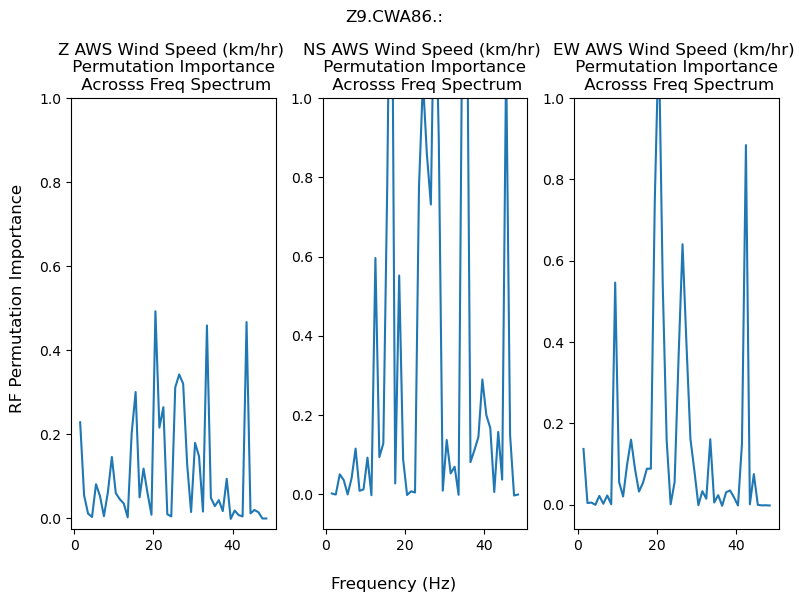

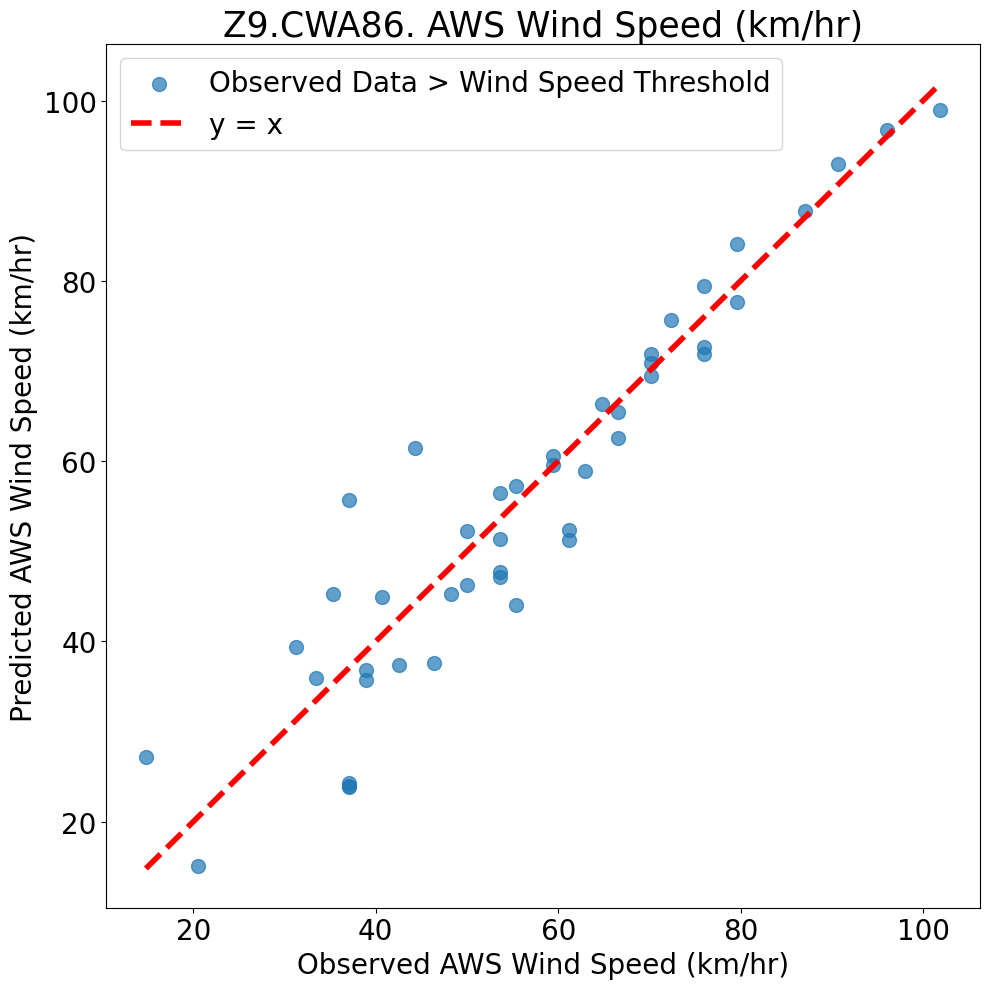

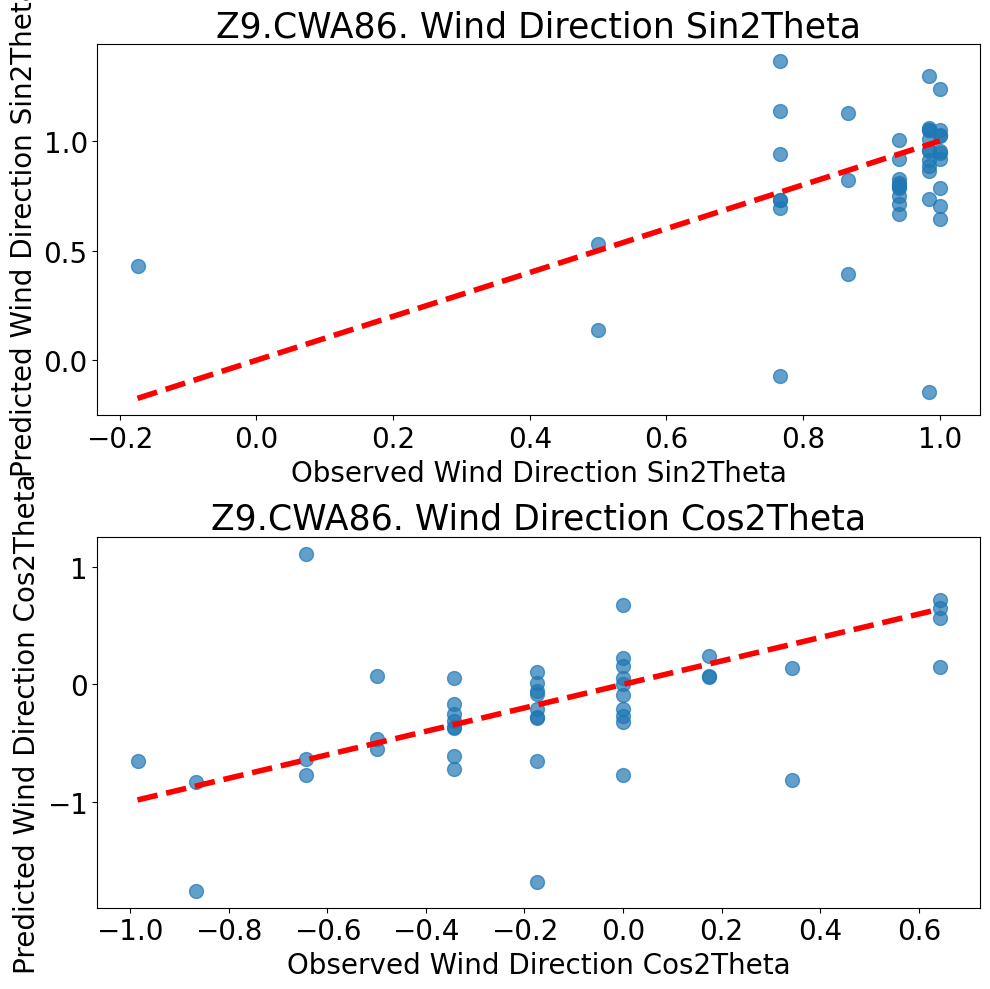

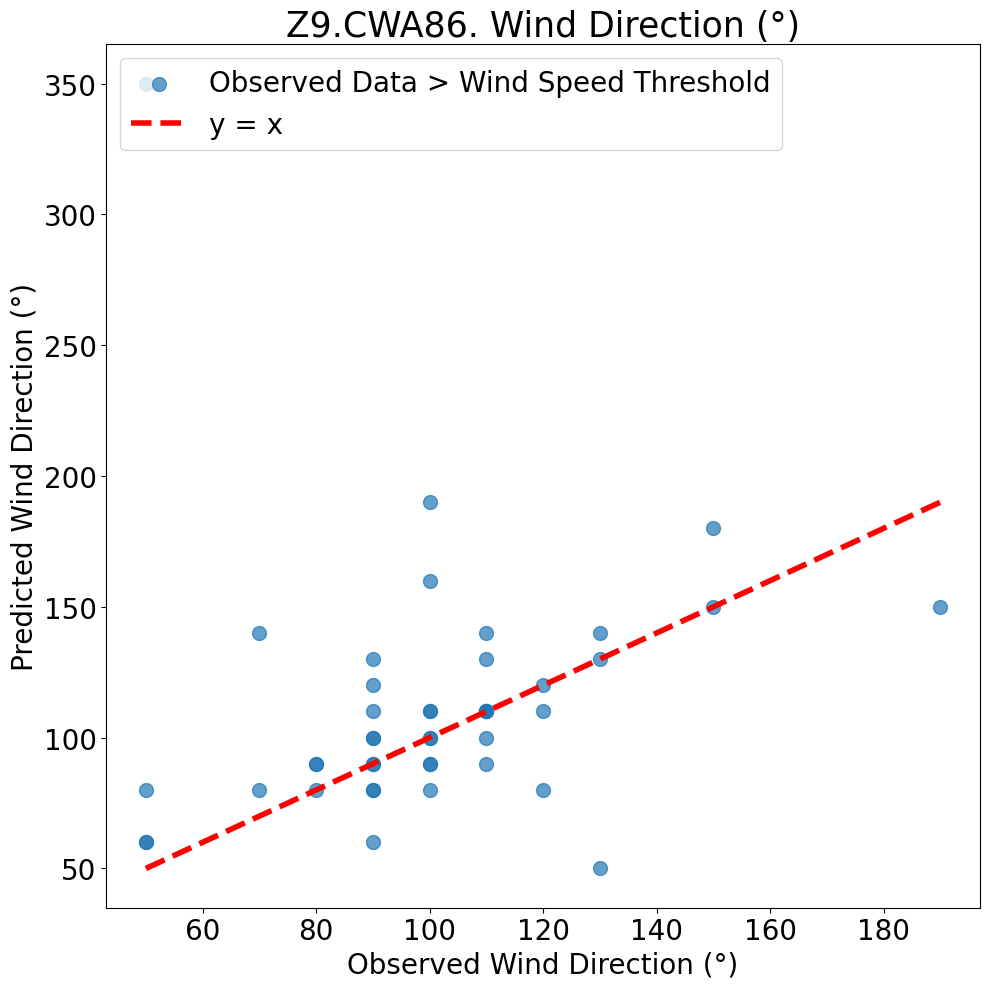

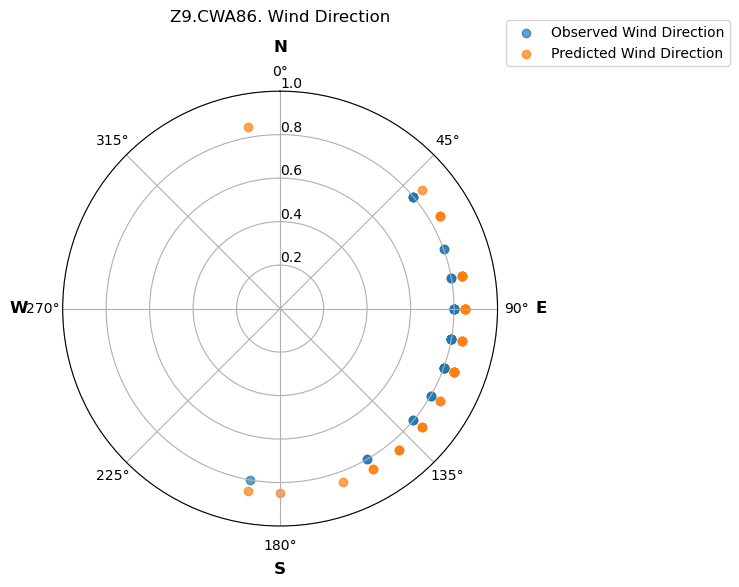

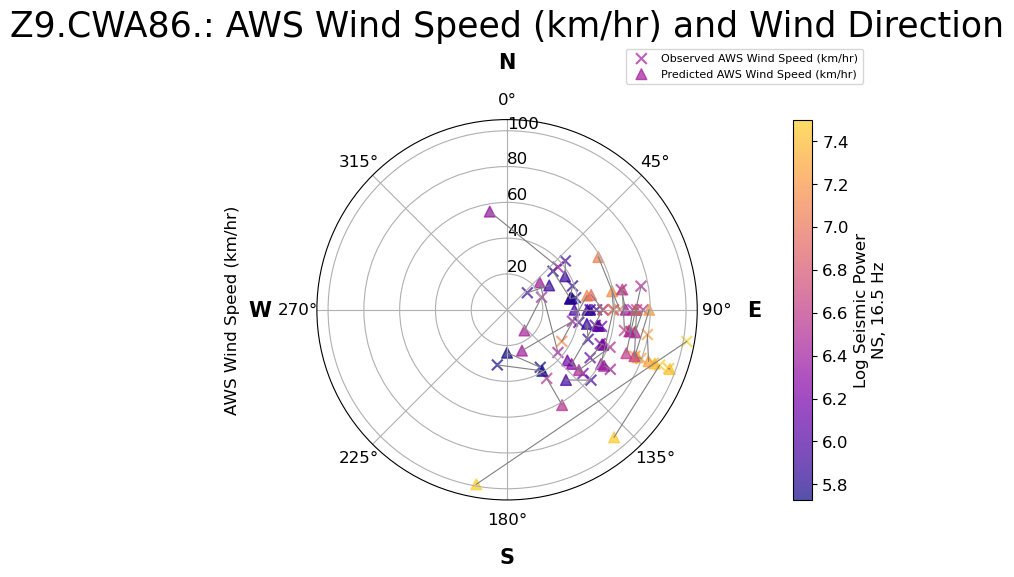

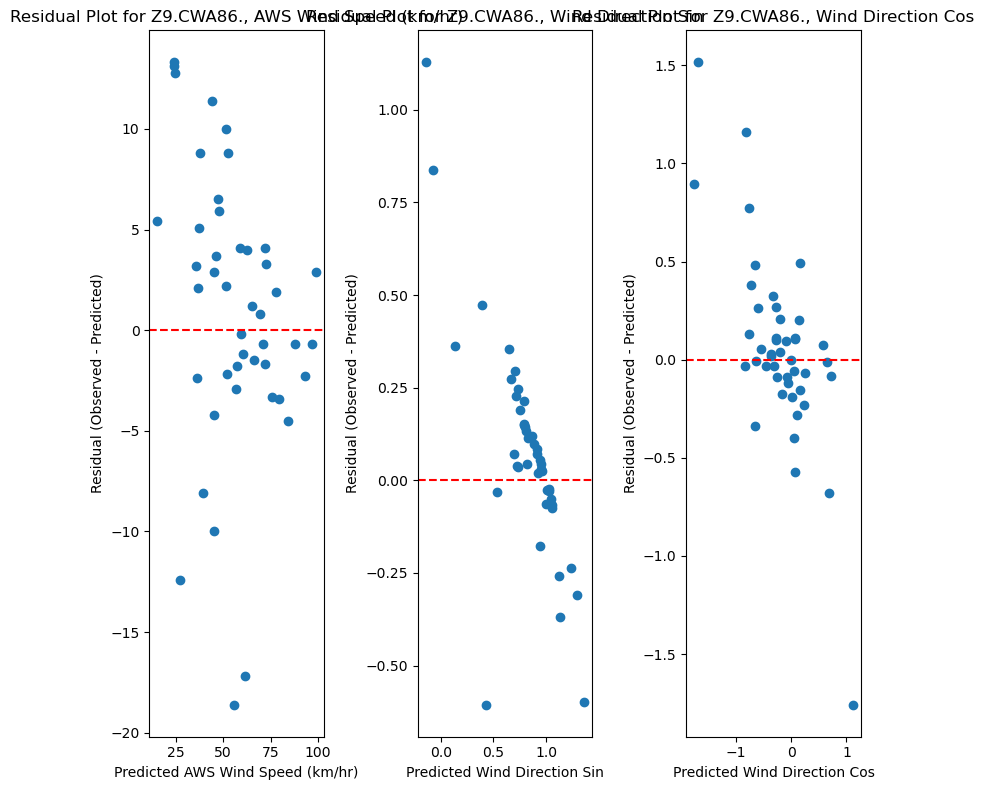

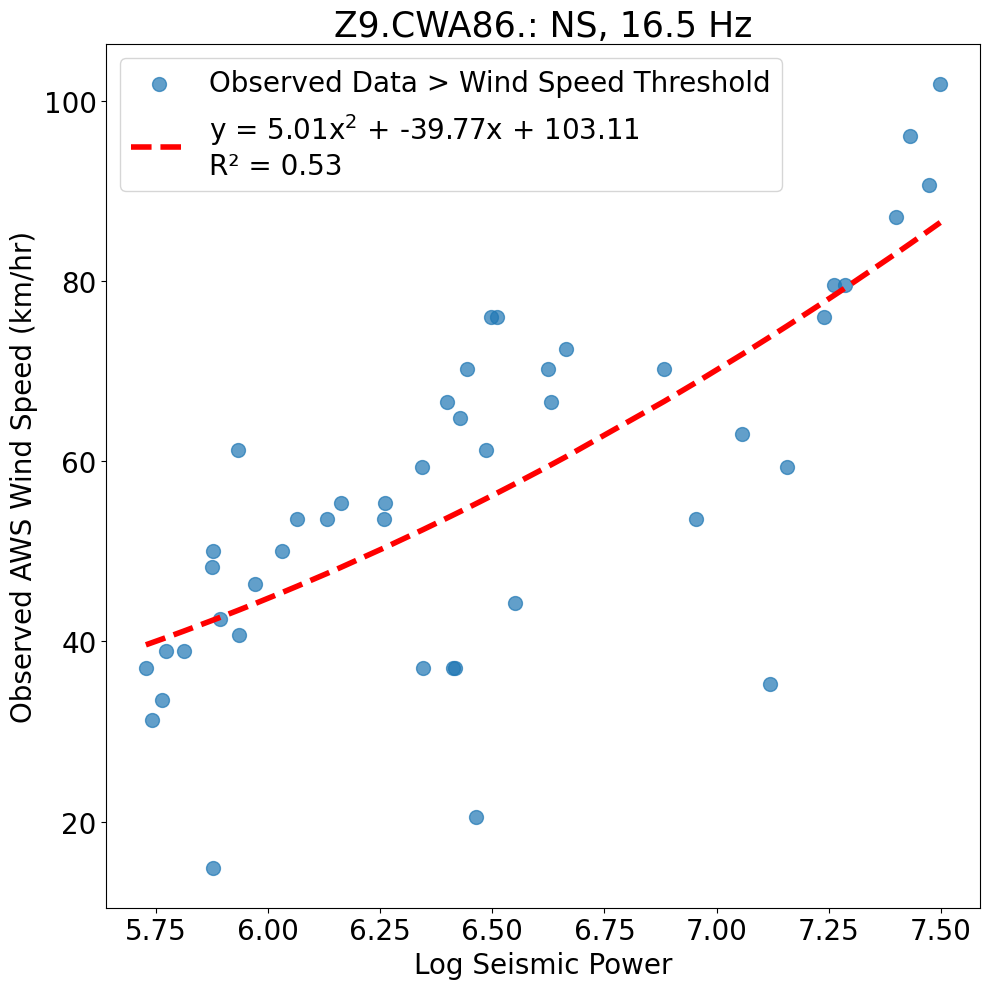

In [34]:
data.wind.seismic_wind.models.Ridge(fmin = 1,
                                    fmax = 49,
                                    f_band_width = 1,
                                    step_size = 1,
                                    n_repeats = 3,
                                    min_WS = 14,
                                    poly_degree = 2,
                                    plot_stat_results = True,
                                    plot_results = True,
                                    plot_residuals = True,
                                    plot_power_aws = True,
                                    variable_name = 'AWS Wind Speed (km/hr)')

In [ ]:
data.wind.seismic_wind.models.EN(fmin = 1,
                                 fmax = 49,
                                 f_band_width = 1,
                                 step_size = 1,
                                 n_repeats = 3,
                                 min_WS = 14,
                                 poly_degree = 2,
                                 plot_stat_results = True,
                                 plot_results = True,
                                 plot_residuals = True,
                                 plot_power_aws = True,
                                 variable_name = 'AWS Wind Speed (km/hr)')

In [ ]:
data.wind.seismic_wind.models.SVR(fmin = 1,
                                 fmax = 49,
                                 f_band_width = 1,
                                 step_size = 1,
                                 n_repeats = 3,
                                 min_WS = 14,
                                 poly_degree = 2,
                                 plot_stat_results = True,
                                 plot_results = True,
                                 plot_residuals = True,
                                 plot_power_aws = True,
                                 variable_name = 'AWS Wind Speed (km/hr)')

In [ ]:
data.wind.seismic_wind.models.RF(fmin = 1,
                                 fmax = 49,
                                 f_band_width = 1,
                                 step_size = 1,
                                 n_repeats = 3,
                                 min_WS = 14,
                                 poly_degree = 2,
                                 plot_stat_results = True,
                                 plot_results = True,
                                 plot_residuals = True,
                                 plot_power_aws = True,
                                 variable_name = 'AWS Wind Speed (km/hr)')